In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COUNTRY_TZ = {
    "AUT": "Europe/Vienna", "BEL": "Europe/Brussels", "BGR": "Europe/Sofia",
    "CHE": "Europe/Zurich", "CZE": "Europe/Prague",   "DEU": "Europe/Berlin",
    "DNK": "Europe/Copenhagen", "ESP": "Europe/Madrid", "FIN": "Europe/Helsinki",
    "FRA": "Europe/Paris",  "GBR": "Europe/London",   "GRC": "Europe/Athens",
    "HRV": "Europe/Zagreb", "HUN": "Europe/Budapest", "IRL": "Europe/Dublin",
    "ITA": "Europe/Rome",   "LUX": "Europe/Luxembourg", "NLD": "Europe/Amsterdam",
    "NOR": "Europe/Oslo",   "POL": "Europe/Warsaw",   "PRT": "Europe/Lisbon",
    "ROU": "Europe/Bucharest", "SVK": "Europe/Bratislava", "SVN": "Europe/Ljubljana",
    "SWE": "Europe/Stockholm",
}

# (label, p_wind, p_solar)
SCENARIOS = [
    ("Low mix · 1% W / 5% S",   0.010, 0.050),
    ("Low mix · 5% W / 1% S",   0.050, 0.010),
    ("High mix · 7% W / 35.5% S",   0.070, 0.355),
    ("High mix · 35.5% W / 7% S",   0.355, 0.070),
]

FEATURED = ["ESP", "ITA", "FRA", "POL", "DNK", "HUN", "SVK"]

In [21]:
df = pd.read_parquet("/Users/ryanaskin/Documents/datasci-challenge/renewables-dataset.parquet")
df["Time"] = pd.to_datetime(df["Time"], utc=True)

featured = [c for c in FEATURED if c in df["country"].unique()]
df = df[df["country"].isin(featured)].copy()

In [ ]:
parts = []
for c, sub in df.groupby("country", sort=False):
    local = sub["Time"].dt.tz_convert(COUNTRY_TZ[c])
    sub = sub.copy()
    sub["hour_local"]  = local.dt.hour.astype("int16")
    sub["month_local"] = local.dt.month.astype("int8")
    parts.append(sub)
df = pd.concat(parts, ignore_index=True)

season_map = {12:"Winter",1:"Winter",2:"Winter",
              3:"Spring",4:"Spring",5:"Spring",
              6:"Summer",7:"Summer",8:"Summer",
              9:"Autumn",10:"Autumn",11:"Autumn"}
df["season"] = df["month_local"].map(season_map)

In [23]:
def scale_to_penetration(df, p_wind, p_solar):
    """
    Return df with wind_scaled_MWh, solar_scaled_MWh, residual_MWh columns
    such that each country's annual scaled wind = p_wind * annual demand,
    and similarly for solar. Hourly shape preserved.

    Replace this with your own penetration-parameter mechanism if different;
    downstream code only requires the residual_MWh column to be populated.
    """
    out = df.copy()
    ann_dem   = out.groupby("country")["demand_MWh"].transform("sum")
    ann_wind  = out.groupby("country")["wind_MWh"].transform("sum")
    ann_solar = out.groupby("country")["solar_MWh"].transform("sum")

    alpha_w = (p_wind  * ann_dem) / ann_wind
    alpha_s = (p_solar * ann_dem) / ann_solar

    out["wind_scaled_MWh"]  = alpha_w * out["wind_MWh"]
    out["solar_scaled_MWh"] = alpha_s * out["solar_MWh"]
    out["residual_MWh"]     = (out["demand_MWh"]
                               - out["wind_scaled_MWh"]
                               - out["solar_scaled_MWh"])
    return out

In [24]:
diurnal_frames = []
for name, p_w, p_s in SCENARIOS:
    d = scale_to_penetration(df, p_w, p_s)
    mean_dem = d.groupby("country")["demand_MWh"].transform("mean")
    d["residual_norm"] = d["residual_MWh"] / mean_dem

    prof = (d.groupby(["country", "hour_local"], as_index=False)["residual_norm"]
              .mean())
    prof["scenario"] = name
    diurnal_frames.append(prof)

diurnal = pd.concat(diurnal_frames, ignore_index=True)

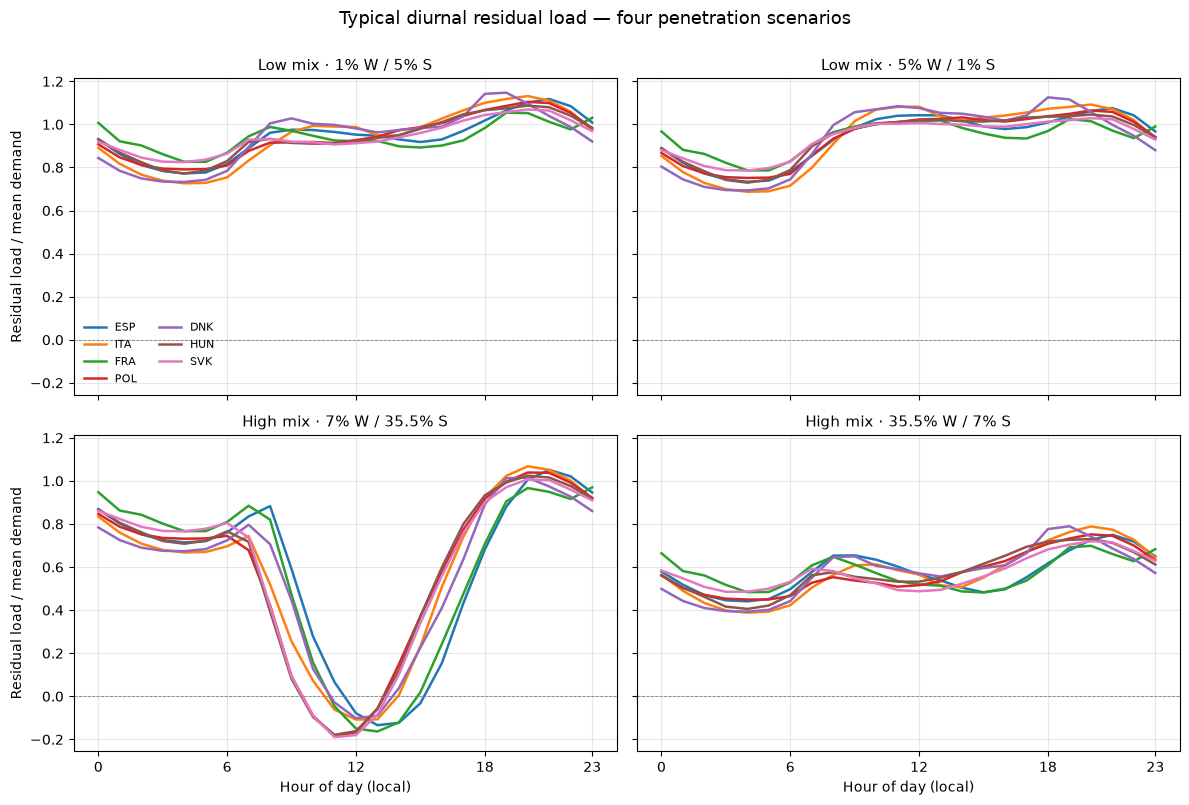

In [26]:
colors = plt.get_cmap("tab10")(np.arange(len(featured)))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (name, _, _) in zip(axes, SCENARIOS):
    sub = diurnal[diurnal["scenario"] == name]
    for i, c in enumerate(featured):
        cs = sub[sub["country"] == c].sort_values("hour_local")
        ax.plot(cs["hour_local"], cs["residual_norm"],
                color=colors[i], label=c, linewidth=1.8)
    ax.set_title(name, fontsize=11)
    ax.axhline(0, color="0.5", linewidth=0.6, linestyle="--")
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.grid(alpha=0.3)

for ax in axes[2:]:
    ax.set_xlabel("Hour of day (local)")
for ax in axes[::2]:
    ax.set_ylabel("Residual load / mean demand")

axes[0].legend(loc="lower left", fontsize=8, ncol=2, frameon=False)
fig.suptitle("Typical diurnal residual load — four penetration scenarios",
             fontsize=13, y=1.00)
fig.tight_layout()
plt.show()

In [27]:
seasonal_frames = []
high_pen = [s for s in SCENARIOS if s[0].startswith("High")]

for name, p_w, p_s in high_pen:
    d = scale_to_penetration(df, p_w, p_s)
    mean_dem = d.groupby("country")["demand_MWh"].transform("mean")
    d["residual_norm"] = d["residual_MWh"] / mean_dem

    prof = (d.groupby(["country", "season", "hour_local"], as_index=False)
              ["residual_norm"].mean())
    prof["scenario"] = name
    seasonal_frames.append(prof)

seasonal = pd.concat(seasonal_frames, ignore_index=True)

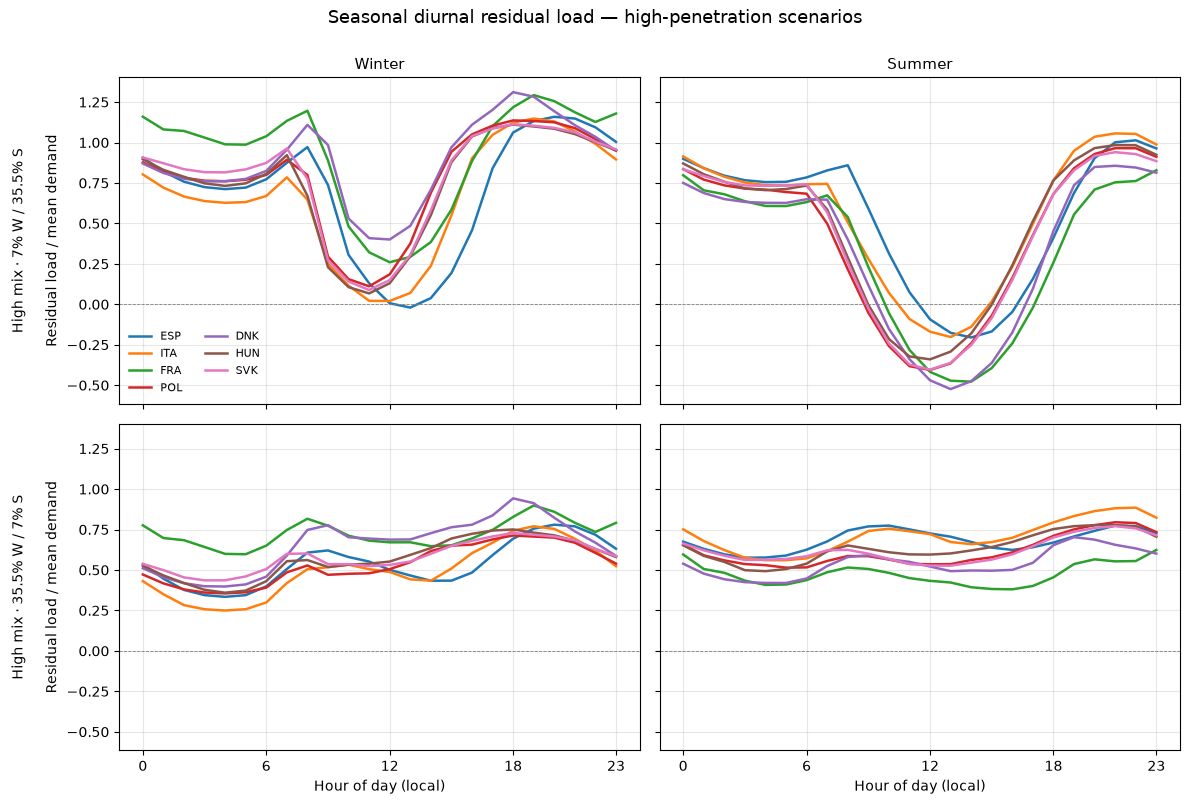

In [ ]:
seasons_to_show = ["Winter", "Summer"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for row, (name, _, _) in enumerate(high_pen):
    for col, season in enumerate(seasons_to_show):
        ax = axes[row, col]
        sub = seasonal[(seasonal["scenario"] == name) & (seasonal["season"] == season)]
        for i, c in enumerate(featured):
            cs = sub[sub["country"] == c].sort_values("hour_local")
            ax.plot(cs["hour_local"], cs["residual_norm"],
                    color=colors[i], label=c, linewidth=1.8)
        ax.axhline(0, color="0.5", linewidth=0.6, linestyle="--")
        ax.set_xticks([0, 6, 12, 18, 23])
        ax.grid(alpha=0.3)
        if row == 0:
            ax.set_title(season, fontsize=11)
        if col == 0:
            ax.set_ylabel(f"{name}\n\nResidual load / mean demand", fontsize=10)

for ax in axes[-1]:
    ax.set_xlabel("Hour of day (local)")

axes[0, 0].legend(loc="lower left", fontsize=8, ncol=2, frameon=False)
fig.suptitle("Seasonal diurnal residual load — high-penetration scenarios",
             fontsize=13, y=1.00)
fig.tight_layout()
plt.show()

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Same dict as before — needs to be in scope
COUNTRY_TZ = {
    "AUT": "Europe/Vienna", "BEL": "Europe/Brussels", "BGR": "Europe/Sofia",
    "CHE": "Europe/Zurich", "CZE": "Europe/Prague",   "DEU": "Europe/Berlin",
    "DNK": "Europe/Copenhagen", "ESP": "Europe/Madrid", "FIN": "Europe/Helsinki",
    "FRA": "Europe/Paris",  "GBR": "Europe/London",   "GRC": "Europe/Athens",
    "HRV": "Europe/Zagreb", "HUN": "Europe/Budapest", "IRL": "Europe/Dublin",
    "ITA": "Europe/Rome",   "LUX": "Europe/Luxembourg", "NLD": "Europe/Amsterdam",
    "NOR": "Europe/Oslo",   "POL": "Europe/Warsaw",   "PRT": "Europe/Lisbon",
    "ROU": "Europe/Bucharest", "SVK": "Europe/Bratislava", "SVN": "Europe/Ljubljana",
    "SWE": "Europe/Stockholm",
}


def carpet_heatmap(dataset_residual, country, scenario_label="",
                   normalise=False, cmap=None, ax=None):
    """
    Hour-of-day × month heatmap of mean residual load for one country.

    Parameters
    ----------
    dataset_residual : DataFrame with columns Time, ID, residual_MWh, demand_MWh
    country          : ISO-3 code (must be a key in COUNTRY_TZ)
    scenario_label   : optional string appended to title (e.g. "1% W / 5% S")
    normalise        : if True, divide residual by country's mean demand
    cmap             : matplotlib cmap name; auto-chosen if None
                       (diverging if residual crosses zero, sequential otherwise)
    ax               : optional existing axes; if None a new figure is made

    Returns
    -------
    pivot : DataFrame (12 × 24) of mean residual by month × hour
    """
    d = dataset_residual.loc[dataset_residual["country"] == country].copy()
    if d.empty:
        raise ValueError(f"No rows for country {country!r} in dataset_residual")
    if country not in COUNTRY_TZ:
        raise KeyError(f"{country!r} not in COUNTRY_TZ — add its IANA timezone")

    # Local calendar fields (single country → no groupby loop needed)
    d["Time"] = pd.to_datetime(d["Time"], utc=True)
    local = d["Time"].dt.tz_convert(COUNTRY_TZ[country])
    d["hour_local"]  = local.dt.hour.astype("int16")
    d["month_local"] = local.dt.month.astype("int8")

    # Choose y-values (absolute MWh vs demand-normalised)
    if normalise:
        d["y"] = d["residual_MWh"] / d["demand_MWh"].mean()
        cbar_label = "Mean residual load / mean demand"
    else:
        d["y"] = d["residual_MWh"]
        cbar_label = "Mean residual load (MWh)"

    # Aggregate: mean per (month, hour) cell
    pivot = (d.groupby(["month_local", "hour_local"])["y"]
              .mean()
              .unstack("hour_local")
              .reindex(index=range(1, 13), columns=range(24)))

    # Auto-choose colormap and normalisation based on sign structure
    vmin, vmax = np.nanmin(pivot.values), np.nanmax(pivot.values)
    if cmap is None:
        if vmin < 0 < vmax:
            cmap = "RdBu_r"
            norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)
        else:
            cmap = "viridis"
            norm = None
    else:
        norm = None

    # Plot
    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(9, 5))
    else:
        fig = ax.figure

    # extent = (left, right, bottom, top); bottom > top puts Jan at top
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, norm=norm,
                   extent=[-0.5, 23.5, 12.5, 0.5], interpolation="nearest")

    ax.set_xticks(range(0, 24, 3))
    ax.set_yticks(range(1, 13))
    ax.set_yticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
    ax.set_xlabel("Hour of day (local)")
    ax.set_ylabel("Month")

    title = f"Residual load carpet — {country}"
    if scenario_label:
        title += f"  ·  {scenario_label}"
    ax.set_title(title, fontsize=12)

    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label(cbar_label)

    if created_fig:
        plt.tight_layout()
        plt.show()

    return pivot

In [11]:
# Make sure this path matches your local file location
dataset = pd.read_parquet("/Users/ryanaskin/Documents/datasci-challenge/renewables-dataset.parquet")

# %% Ensure the time column is parsed as datetime
dataset["Time"] = pd.to_datetime(dataset["Time"])
a_s = 0.01  # solar matches (a_s x 100)% of the average yearly demand across EU
a_w = 0.05  # wind matches (a_w x 100)% of the average yearly demand across EU


# Compute scaled supply and residual load
dataset_residual = dataset.assign(
    solar_scaled_MWh=lambda df: a_s * df["solar_MWh"],
    wind_scaled_MWh=lambda df: a_w * df["wind_MWh"],
    supply_scaled_MWh=lambda df: df["solar_scaled_MWh"] + df["wind_scaled_MWh"],
    residual_MWh=lambda df: df["demand_MWh"] - df["supply_scaled_MWh"],
)[
    [
        "Time",
        "ID",
        "country",
        "solar_scaled_MWh",
        "wind_scaled_MWh",
        "demand_MWh",
        "supply_scaled_MWh",
        "residual_MWh",
    ]
]

# Optional: inspect the result
print(dataset_residual.head())

                       Time ID country  solar_scaled_MWh  wind_scaled_MWh  \
0 2012-01-01 00:00:00+00:00  1     POR               0.0         0.915082   
1 2012-01-01 00:00:00+00:00  2     POR               0.0         0.619641   
2 2012-01-01 00:00:00+00:00  3     POR               0.0         0.685508   
3 2012-01-01 00:00:00+00:00  4     POR               0.0         0.782409   
4 2012-01-01 00:00:00+00:00  5     POR               0.0         0.205369   

   demand_MWh  supply_scaled_MWh  residual_MWh  
0     75.6549           0.915082     74.739818  
1    557.8868           0.619641    557.267159  
2     15.5237           0.685508     14.838192  
3      8.6425           0.782409      7.860091  
4     85.3649           0.205369     85.159531  


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Align keys to the codes that appear in dataset_residual["country"].unique()
COUNTRY_TZ = {
    "AUT": "Europe/Vienna",   "BEL": "Europe/Brussels",   "BGR": "Europe/Sofia",
    "CHE": "Europe/Zurich",   "CZE": "Europe/Prague",     "DEU": "Europe/Berlin",
    "DNK": "Europe/Copenhagen","ESP": "Europe/Madrid",    "FIN": "Europe/Helsinki",
    "FRA": "Europe/Paris",    "GBR": "Europe/London",     "GRC": "Europe/Athens",
    "HRV": "Europe/Zagreb",   "HUN": "Europe/Budapest",   "IRL": "Europe/Dublin",
    "ITA": "Europe/Rome",     "LUX": "Europe/Luxembourg", "NLD": "Europe/Amsterdam",
    "NOR": "Europe/Oslo",     "POL": "Europe/Warsaw",     "POR": "Europe/Lisbon",
    "ROU": "Europe/Bucharest","SVK": "Europe/Bratislava", "SVN": "Europe/Ljubljana",
    "SWE": "Europe/Stockholm",
}


def carpet_heatmap(dataset_residual, country, scenario_label="",
                   normalise=False, cmap=None, ax=None):
    """
    Hour-of-day × month heatmap of mean residual load for one country.
    Aggregates over all sub-country IDs (sums MWh per timestamp).

    dataset_residual : DataFrame with columns Time, ID, country,
                       residual_MWh, demand_MWh
    country          : code as it appears in dataset_residual["country"]
                       (e.g. "POR", "ESP", "DEU")
    """
    d = dataset_residual.loc[dataset_residual["country"] == country]
    if d.empty:
        raise ValueError(f"No rows for country {country!r}. "
                         f"Available: {sorted(dataset_residual['country'].unique())}")
    if country not in COUNTRY_TZ:
        raise KeyError(f"{country!r} not in COUNTRY_TZ — add its IANA timezone")

    # Sum across sub-country IDs → one row per hour
    hourly = (d.groupby("Time", as_index=False)
               [["residual_MWh", "demand_MWh"]].sum())
    hourly["Time"] = pd.to_datetime(hourly["Time"], utc=True)

    # Local calendar fields (single country → no per-country loop needed)
    local = hourly["Time"].dt.tz_convert(COUNTRY_TZ[country])
    hourly["hour_local"]  = local.dt.hour.astype("int16")
    hourly["month_local"] = local.dt.month.astype("int8")

    # Value to plot
    if normalise:
        hourly["y"] = hourly["residual_MWh"] / hourly["demand_MWh"].mean()
        cbar_label = "Mean residual load / mean demand"
    else:
        hourly["y"] = hourly["residual_MWh"]
        cbar_label = "Mean residual load (MWh)"

    # Aggregate: mean per (month, hour) cell
    pivot = (hourly.groupby(["month_local", "hour_local"])["y"]
                    .mean()
                    .unstack("hour_local")
                    .reindex(index=range(1, 13), columns=range(24)))

    # Auto colormap: diverging around zero if residual crosses zero, else sequential
    vmin, vmax = np.nanmin(pivot.values), np.nanmax(pivot.values)
    if cmap is None:
        if vmin < 0 < vmax:
            cmap, norm = "RdBu_r", TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)
        else:
            cmap, norm = "viridis", None
    else:
        norm = None

    # Plot
    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(9, 5))
    else:
        fig = ax.figure

    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, norm=norm,
                   extent=[-0.5, 23.5, 12.5, 0.5], interpolation="nearest")

    ax.set_xticks(range(0, 24, 3))
    ax.set_yticks(range(1, 13))
    ax.set_yticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
    ax.set_xlabel("Hour of day (local)")
    ax.set_ylabel("Month")

    title = f"Residual load carpet — {country}"
    if scenario_label:
        title += f"  ·  {scenario_label}"
    ax.set_title(title, fontsize=12)

    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label(cbar_label)

    if created_fig:
        plt.tight_layout()
        plt.show()

    return pivot

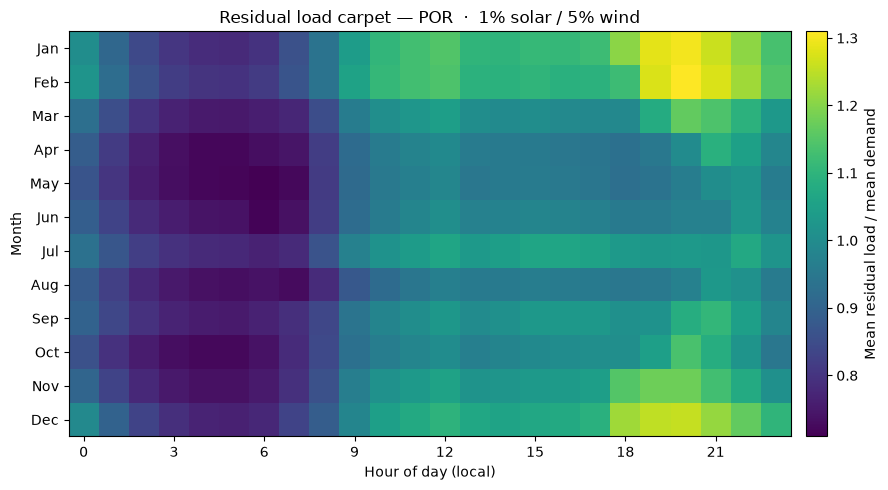

hour_local,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
month_local,,,,,,,,,,,,,,,,,,,,,
1,1.003354,0.910481,0.841890,0.804999,0.785611,0.780453,0.796427,0.858427,0.938760,1.040617,...,1.100580,1.112399,1.110275,1.120376,1.205645,1.285028,1.299014,1.262038,1.208285,1.134975
2,1.019076,0.924217,0.855477,0.818300,0.800517,0.797027,0.814335,0.866589,0.938075,1.054888,...,1.093953,1.101269,1.090493,1.096443,1.120294,1.276202,1.309906,1.276584,1.223648,1.147971
3,0.929265,0.853157,0.796958,0.767295,0.752225,0.749691,0.760277,0.774580,0.850754,0.962244,...,0.997338,1.004196,0.993139,0.989199,0.990336,1.079675,1.164605,1.141144,1.095002,1.028570
4,0.885930,0.814037,0.761078,0.733873,0.720542,0.719342,0.732636,0.743564,0.818155,0.920144,...,0.955485,0.956105,0.947113,0.942422,0.931461,0.950683,0.999507,1.091142,1.051525,0.984387
5,0.866348,0.803100,0.755364,0.732019,0.720359,0.718104,0.709454,0.723382,0.814715,0.917964,...,0.953743,0.958782,0.951851,0.946043,0.928529,0.938398,0.964398,1.004946,1.019787,0.960818
6,0.889476,0.829989,0.781309,0.756428,0.741985,0.738997,0.714420,0.736124,0.818983,0.922449,...,0.975555,0.982208,0.977628,0.971390,0.954078,0.958731,0.973083,0.972755,1.025383,0.975820
7,0.933123,0.870929,0.821680,0.795317,0.780819,0.777490,0.766883,0.780092,0.862455,0.973464,...,1.045461,1.061481,1.061424,1.055071,1.032429,1.027105,1.034098,1.027828,1.071877,1.021264
8,0.881815,0.822449,0.776931,0.749940,0.735572,0.732165,0.738542,0.727632,0.783267,0.874436,...,0.954146,0.963013,0.959528,0.955846,0.946400,0.952493,0.972527,1.028913,1.013033,0.960316
9,0.897492,0.838311,0.795083,0.769868,0.755910,0.753380,0.766913,0.790281,0.838142,0.940500,...,1.011104,1.029695,1.030418,1.029134,1.011194,1.014987,1.084111,1.107355,1.047494,0.982333


In [13]:
carpet_heatmap(
    dataset_residual,
    country="POR",
    scenario_label=f"{int(a_s*100)}% solar / {int(a_w*100)}% wind",
    normalise=True,
)